# A/B test analysis: landing pages and billing page

Phase 1 found five website experiments: pairs of pages that received traffic on the same days, in the same
traffic segment, with a roughly 50/50 split. This notebook checks each one properly:

| Test | Pages (A vs B) | Segment | Both live |
|---|---|---|---|
| T1 | /home vs /lander-1 | gsearch nonbrand, all devices | 2012-06-19 to 2012-07-29 |
| T2 | /lander-1 vs /lander-2 | paid nonbrand (gsearch + bsearch), all devices | 2013-01-14 to 2013-03-10 |
| T3 | /billing vs /billing-2 | all sessions that reached billing | 2012-09-10 to 2013-01-05 |
| T4 | /lander-2 vs /lander-4 | paid nonbrand, desktop | 2014-02-02 to 2014-04-19 |
| T5 | /lander-2 vs /lander-5 | paid nonbrand, desktop | 2014-08-02 to 2014-11-10 |

For each test: definition, sample ratio mismatch check, metrics and significance, practical impact,
segment check (Simpson's paradox), power, and a novelty / post-rollout check.

## How to read the statistics

**Why only the test window and the test segment.** Conversion moves with the season, ad bids, product launches and
site changes. Comparing /home in May with /lander-1 in August would mix the page effect with the month effect.
Inside the window both pages get the same kind of traffic on the same days, split at random, so the page is the
only systematic difference. The segment matters for the same reason: /home also serves brand, organic and direct
visitors, who convert better than paid nonbrand visitors. Including them would bias the test against the lander.

**Sample ratio mismatch (SRM), chi-square goodness-of-fit.**
*What it checks:* whether the observed A/B session counts match the intended split (50/50).
*Assumptions:* sessions are independent; expected counts are large (at least 5 per group).
*How to read it:* a very small p-value (below 0.01 is the usual SRM alarm) means the split is broken
(a redirect losing sessions, bots, a tracking bug) and the result should not be trusted until that is fixed.
A large p-value means the split is consistent with 50/50.

**Two-proportion z-test.**
*What it checks:* whether the two conversion rates differ by more than random noise would explain.
The null hypothesis is that both pages have the same true rate.
*Assumptions:* each session is in one group only; sessions are independent; enough conversions in each group
(roughly n x p >= 10) for the normal approximation to hold.
*How to read it:* the p-value is the chance of seeing a gap at least this large if the pages were truly equal.
Below 0.05, we reject "no difference".

**Chi-square test of independence (2x2 table: variant x converted).**
*What it checks:* the same question framed as "is converting independent of which page you saw?".
It compares the observed counts with the counts expected if the page made no difference.
*Assumptions:* independent sessions, expected count of at least 5 in every cell.
*How to read it:* without the continuity correction, chi-square = z squared and the p-values match the z-test exactly,
so it is a useful cross-check.

**95% confidence interval for the difference (B - A).**
The range of true differences that are consistent with the data. If it excludes 0 the result is significant at 5%.
Its width shows how precise the estimate is, and its ends give the best and worst plausible business impact,
which a p-value alone does not.

**Relative lift and practical significance.**
Lift = (B - A) / A. A significant result can be too small to matter, and a big-looking lift can be noise.
So each result is also turned into incremental orders and revenue per month for the segment.

**Power and minimum detectable effect (MDE).**
Power is the chance a test detects a real effect of a given size. The MDE is the smallest true lift the test would
catch 80% of the time at alpha = 0.05, given its sample size and baseline rate. If the MDE is larger than the lift
you could realistically expect, the test was underpowered, and "not significant" means "not enough data",
not "no effect".

**Simpson's paradox.**
A difference that holds inside every subgroup can shrink, vanish or reverse when the groups are pooled, if the
subgroups are mixed in different proportions in A and B. For example, if B got more desktop traffic (which converts
better) it could look better overall while being worse on each device. The check: compare the lift within each
device and compare the device mix of A and B.

In [1]:
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.append(str(Path.cwd().parent / "src"))
from ab_testing import (TESTS, build_test, compare_rates, load_sessions, mde, sample_size_needed,
                        srm_check, summary_table)
from chart_style import HIGHLIGHT, TEXT_MUTED, VARIANT_COLORS, apply_style
from db import get_engine

apply_style()
pd.set_option("display.float_format", "{:,.4f}".format)
IMAGES = Path.cwd().parent / "images"
TEST = {t["test"]: t for t in TESTS}

In [2]:
sessions = load_sessions(get_engine())
print(f"{len(sessions):,} sessions loaded")
sessions.head(3)

472,871 sessions loaded


,website_session_id,created_at,channel_group,utm_source,device_type,landing_page,billing_page,is_bounce,saw_billing,has_order,revenue_usd
0,1,2012-03-19 08:04:16,paid_nonbrand,gsearch,mobile,/home,NaN,1,0,0,0.0000
1,2,2012-03-19 08:16:49,paid_nonbrand,gsearch,desktop,/home,NaN,1,0,0,0.0000
2,3,2012-03-19 08:26:55,paid_nonbrand,gsearch,desktop,/home,NaN,1,0,0,0.0000


### Helper functions used for every test

In [3]:
def split_check(t, segment_col="device_type"):
    counts = pd.crosstab(t[segment_col], t["variant"], margins=True, margins_name="total")
    srm = srm_check((t["variant"] == "A").sum(), (t["variant"] == "B").sum())
    print(f"window: {t['created_at'].min():%Y-%m-%d} to {t['created_at'].max():%Y-%m-%d}")
    print(f"share of sessions in A: {srm['share_a']:.2%}   SRM chi2 = {srm['chi2']:.3f}, p = {srm['p_value']:.3f}")
    return counts


def metric_table(t, metrics):
    a, b = t[t["variant"] == "A"], t[t["variant"] == "B"]
    rows = {m: compare_rates(a[m].sum(), len(a), b[m].sum(), len(b)) for m in metrics}
    table = pd.DataFrame(rows).T
    return table[["rate_a", "rate_b", "diff", "ci_low", "ci_high", "rel_lift", "z", "p_value_z", "chi2", "p_value_chi2"]]


def impact(t, test):
    days = (pd.Timestamp(test["end"]) - pd.Timestamp(test["start"])).days + 1
    monthly_sessions = len(t) / days * 30.4
    res = compare_rates(t.loc[t["variant"] == "A", "has_order"].sum(), (t["variant"] == "A").sum(),
                        t.loc[t["variant"] == "B", "has_order"].sum(), (t["variant"] == "B").sum())
    rps = t.groupby("variant")["revenue_usd"].mean()
    return pd.Series({
        "segment sessions per month": monthly_sessions,
        "revenue per session A": rps["A"],
        "revenue per session B": rps["B"],
        "incremental orders per month": res["diff"] * monthly_sessions,
        "  (95% CI low)": res["ci_low"] * monthly_sessions,
        "  (95% CI high)": res["ci_high"] * monthly_sessions,
        "incremental revenue per month": (rps["B"] - rps["A"]) * monthly_sessions,
    })


def segment_check(t, segment_col, metric="has_order"):
    rows = []
    for seg, g in t.groupby(segment_col):
        a, b = g[g["variant"] == "A"], g[g["variant"] == "B"]
        r = compare_rates(a[metric].sum(), len(a), b[metric].sum(), len(b))
        rows.append({segment_col: seg, "sessions_a": len(a), "sessions_b": len(b), "rate_a": r["rate_a"],
                     "rate_b": r["rate_b"], "diff": r["diff"], "rel_lift": r["rel_lift"], "p_value": r["p_value_z"]})
    counts = pd.crosstab(t[segment_col], t["variant"])
    mix_p = stats.chi2_contingency(counts)[1]
    print(f"{segment_col} mix, share of each variant's sessions:")
    print(pd.crosstab(t[segment_col], t["variant"], normalize="columns").round(4).to_string())
    print(f"chi-square test that the mix is the same in A and B: p = {mix_p:.3f}")
    return pd.DataFrame(rows).set_index(segment_col)


def power_check(t, metric="has_order"):
    a, b = t[t["variant"] == "A"], t[t["variant"] == "B"]
    base, observed = a[metric].mean(), b[metric].mean()
    m = mde(base, min(len(a), len(b)))
    return pd.Series({
        "sessions per variant": min(len(a), len(b)),
        "baseline rate (A)": base,
        "MDE absolute (80% power)": m["mde_abs"],
        "MDE relative": m["mde_rel"],
        "observed relative lift": observed / base - 1,
        "sessions per variant needed for the observed lift": sample_size_needed(base, observed),
    })


def halves_check(t, metric="has_order"):
    mid = t["created_at"].min() + (t["created_at"].max() - t["created_at"].min()) / 2
    t = t.assign(half=np.where(t["created_at"] < mid, "1st half", "2nd half"))
    out = t.groupby(["half", "variant"])[metric].mean().unstack()
    out["rel_lift"] = out["B"] / out["A"] - 1
    return out


def post_test_check(sessions, test, weeks=8, metric="has_order"):
    seg = sessions.query(test["segment"])
    page = seg[seg[test["page_col"]] == test["b"]]
    end = pd.Timestamp(test["end"]) + pd.Timedelta(days=1)
    periods = {
        "during test": (pd.Timestamp(test["start"]), end),
        f"first {weeks} weeks after rollout": (end, end + pd.Timedelta(weeks=weeks)),
    }
    rows = []
    for label, (lo, hi) in periods.items():
        x = page[(page["created_at"] >= lo) & (page["created_at"] < hi)]
        rows.append({"period": label, "sessions": len(x), "rate": x[metric].mean()})
    return pd.DataFrame(rows).set_index("period")


def plot_cumulative(ax, t, title, metric="has_order"):
    daily = t.groupby([t["created_at"].dt.date, "variant"])[metric].agg(["sum", "count"]).unstack().cumsum()
    for v, label in [("A", "A (control)"), ("B", "B (new page)")]:
        ax.plot(daily.index, daily[("sum", v)] / daily[("count", v)], color=VARIANT_COLORS[v], label=label)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    locator = mdates.AutoDateLocator(maxticks=5)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

## T1: /home vs /lander-1

**Definition.** /lander-1 first received traffic on 2012-06-19. From then until 2012-07-29, gsearch nonbrand traffic
was split between /home and /lander-1; from 2012-07-30 all of it went to /lander-1. The test population is
gsearch nonbrand sessions in that window (bsearch nonbrand had not started yet, and brand, organic and direct
traffic always landed on /home, so they are excluded).

**Metrics.** Bounce rate (did the page make visitors click further) and order conversion (did it make them buy).

In [4]:
t1 = build_test(sessions, TEST["T1"])
split_check(t1)

window: 2012-06-19 to 2012-07-29
share of sessions in A: 49.44%   SRM chi2 = 0.597, p = 0.440


variant,A,B,total
device_type,,,
desktop,1766,1827,3593
mobile,562,554,1116
total,2328,2381,4709


In [5]:
metric_table(t1, ["has_order", "is_bounce"])

,rate_a,rate_b,diff,ci_low,ci_high,rel_lift,z,p_value_z,chi2,p_value_chi2
has_order,0.0322,0.0403,0.0081,-0.0026,0.0188,0.2515,1.4861,0.1373,2.2084,0.1373
is_bounce,0.5863,0.5300,-0.0563,-0.0846,-0.0280,-0.0960,-3.8901,0.0001,15.1326,0.0001


In [6]:
impact(t1, TEST["T1"])

segment sessions per month      3,491.5512
revenue per session A               1.6105
revenue per session B               2.0156
incremental orders per month       28.2910
  (95% CI low)                     -8.9682
  (95% CI high)                    65.5502
incremental revenue per month   1,414.2665
dtype: float64

In [7]:
segment_check(t1, "device_type")

device_type mix, share of each variant's sessions:
variant          A      B
device_type              
desktop     0.7586 0.7673
mobile      0.2414 0.2327
chi-square test that the mix is the same in A and B: p = 0.503


,sessions_a,sessions_b,rate_a,rate_b,diff,rel_lift,p_value
device_type,,,,,,,
desktop,1766,1827,0.0396,0.0465,0.0069,0.1737,0.3097
mobile,562,554,0.0089,0.0199,0.0110,1.2318,0.1236


In [8]:
power_check(t1)

sessions per variant                                2,328.0000
baseline rate (A)                                       0.0322
MDE absolute (80% power)                                0.0161
MDE relative                                            0.4985
observed relative lift                                  0.2515
sessions per variant needed for the observed lift   8,331.5593
dtype: float64

In [9]:
display(halves_check(t1))
post_test_check(sessions, TEST["T1"])

variant,A,B,rel_lift
half,,,
1st half,0.0265,0.0374,0.4081
2nd half,0.0376,0.0432,0.1498


,sessions,rate
period,,
during test,2381,0.0403
first 8 weeks after rollout,8239,0.0379


**Interpretation (T1)**
- The split is clean: 2,328 vs 2,381 sessions (49.4% in A), SRM p = 0.44.
- /lander-1 clearly cut bounce: 58.6% to 53.0%, a drop of 5.6 points (95% CI 2.8 to 8.5 points), p = 0.0001.
- Order conversion went from 3.22% to 4.03% (+25% relative), but p = 0.137 and the CI (-0.26 to +1.88 points)
  includes zero, so the conversion gain is not proven.
- The test was underpowered for conversion. With 2,328 sessions per page it could only reliably detect a lift of
  about 50%. Detecting the observed 25% would have needed about 8,300 sessions per page, 3.6 times more.
  "Not significant" here means "not enough data", not "no effect".
- Both devices point the same way (desktop +17%, mobile from 0.89% to 1.99%) and the device mix is the same in A and B
  (p = 0.50), so there is no Simpson's paradox.
- The lift was larger in the first half (+41%) than the second (+15%), a possible sign of fading. But /lander-1
  converted at 3.79% in the 8 weeks after rollout vs 4.03% during the test, so it roughly held.
- Rolling out /lander-1 was reasonable on the bounce result with no sign of harm. The expected conversion gain
  (+28 orders a month, CI -9 to +66) is a best estimate, not a proven result.

## T2: /lander-1 vs /lander-2

**Definition.** /lander-2 first received traffic on 2013-01-14 and shared paid nonbrand traffic (gsearch and bsearch,
both devices) with /lander-1 until 2013-03-10. The window includes the Forever Love Bear launch (2013-01-06, just
before) and Valentine's Day. That is fine for the comparison because both pages were live on the same days,
but it would make a before/after comparison meaningless.

**Metrics.** Bounce rate and order conversion.

In [10]:
t2 = build_test(sessions, TEST["T2"])
split_check(t2)

window: 2013-01-14 to 2013-03-10
share of sessions in A: 49.95%   SRM chi2 = 0.008, p = 0.928


variant,A,B,total
device_type,,,
desktop,3887,3851,7738
mobile,1070,1115,2185
total,4957,4966,9923


In [11]:
metric_table(t2, ["has_order", "is_bounce"])

,rate_a,rate_b,diff,ci_low,ci_high,rel_lift,z,p_value_z,chi2,p_value_chi2
has_order,0.0577,0.0638,0.0061,-0.0033,0.0155,0.1064,1.2796,0.2007,1.6375,0.2007
is_bounce,0.5384,0.4766,-0.0618,-0.0814,-0.0422,-0.1148,-6.1558,0.0000,37.8938,0.0000


In [12]:
impact(t2, TEST["T2"])

segment sessions per month      5,386.7714
revenue per session A               3.0456
revenue per session B               3.3622
incremental orders per month       33.0634
  (95% CI low)                    -17.5720
  (95% CI high)                    83.6988
incremental revenue per month   1,705.4994
dtype: float64

In [13]:
display(segment_check(t2, "device_type"))
segment_check(t2, "utm_source")

device_type mix, share of each variant's sessions:
variant          A      B
device_type              
desktop     0.7841 0.7755
mobile      0.2159 0.2245
chi-square test that the mix is the same in A and B: p = 0.309


,sessions_a,sessions_b,rate_a,rate_b,diff,rel_lift,p_value
device_type,,,,,,,
desktop,3887,3851,0.0669,0.0748,0.0079,0.1180,0.1758
mobile,1070,1115,0.0243,0.0260,0.0017,0.0704,0.7987


utm_source mix, share of each variant's sessions:
variant         A      B
utm_source              
bsearch    0.1761 0.1712
gsearch    0.8239 0.8288
chi-square test that the mix is the same in A and B: p = 0.532


,sessions_a,sessions_b,rate_a,rate_b,diff,rel_lift,p_value
utm_source,,,,,,,
bsearch,873,850,0.0710,0.0635,-0.0075,-0.1055,0.5351
gsearch,4084,4116,0.0548,0.0639,0.0090,0.1650,0.0830


In [14]:
power_check(t2)

sessions per variant                                 4,957.0000
baseline rate (A)                                        0.0577
MDE absolute (80% power)                                 0.0138
MDE relative                                             0.2394
observed relative lift                                   0.1064
sessions per variant needed for the observed lift   23,766.2907
dtype: float64

In [15]:
display(halves_check(t2))
post_test_check(sessions, TEST["T2"])

variant,A,B,rel_lift
half,,,
1st half,0.0555,0.0595,0.0726
2nd half,0.0593,0.0669,0.1294


,sessions,rate
period,,
during test,4966,0.0638
first 8 weeks after rollout,10957,0.0691


**Interpretation (T2)**
- Split: 4,957 vs 4,966 sessions, SRM p = 0.93.
- Bounce fell from 53.8% to 47.7% (-6.2 points, CI 4.2 to 8.1 points), p < 0.001.
- Conversion went from 5.77% to 6.38% (+10.6% relative), p = 0.20, CI -0.33 to +1.55 points: not significant.
- MDE was about 24% relative. Detecting a 10.6% lift would have needed about 23,800 sessions per page, almost
  five times what the test had.
- Desktop (+11.8%) and mobile (+7.0%) both lean positive, and the device mix is balanced (p = 0.31).
  By source, gsearch is +16.5% (p = 0.083) while bsearch is -10.6% on only ~860 sessions per page (p = 0.54).
  That is too small to call a real difference between engines.
- There was no novelty fade: the lift was +7% in the first half and +13% in the second, and /lander-2 converted
  at 6.91% in the 8 weeks after rollout.
- Same pattern as T1: a clear engagement win with a positive but unproven conversion effect.

## T3: /billing vs /billing-2

**Definition.** /billing-2 first appeared on 2012-09-10; both billing pages were live until 2013-01-05, and
/billing-2 took all traffic from 2013-01-06. The test population is every session that reached a billing page in
that window, from any channel.

**Metric.** Billing-to-order conversion: of the sessions that saw the billing page, the share that placed an order.
Using all sessions as the denominator would dilute the effect with visitors who never saw either billing page.
Bounce is not relevant here (a billing session has already viewed several pages).

In [16]:
t3 = build_test(sessions, TEST["T3"])
split_check(t3)

window: 2012-09-10 to 2013-01-05
share of sessions in A: 50.08%   SRM chi2 = 0.008, p = 0.931


variant,A,B,total
device_type,,,
desktop,1491,1464,2955
mobile,172,194,366
total,1663,1658,3321


In [17]:
metric_table(t3, ["has_order"])

,rate_a,rate_b,diff,ci_low,ci_high,rel_lift,z,p_value_z,chi2,p_value_chi2
has_order,0.4510,0.6212,0.1702,0.1368,0.2037,0.3775,9.8360,0.0000,96.7469,0.0000


In [18]:
impact(t3, TEST["T3"])

segment sessions per month        855.5797
revenue per session A              22.5451
revenue per session B              31.0553
incremental orders per month      145.6524
  (95% CI low)                    117.0560
  (95% CI high)                   174.2487
incremental revenue per month   7,281.1612
dtype: float64

In [19]:
segment_check(t3, "device_type")

device_type mix, share of each variant's sessions:
variant          A      B
device_type              
desktop     0.8966 0.8830
mobile      0.1034 0.1170
chi-square test that the mix is the same in A and B: p = 0.232


,sessions_a,sessions_b,rate_a,rate_b,diff,rel_lift,p_value
device_type,,,,,,,
desktop,1491,1464,0.4634,0.6380,0.1745,0.3766,0.0000
mobile,172,194,0.3430,0.4948,0.1518,0.4426,0.0033


In [20]:
power_check(t3)

sessions per variant                                1,658.0000
baseline rate (A)                                       0.4510
MDE absolute (80% power)                                0.0486
MDE relative                                            0.1077
observed relative lift                                  0.3775
sessions per variant needed for the observed lift     133.3703
dtype: float64

In [21]:
display(halves_check(t3))
post_test_check(sessions, TEST["T3"])

variant,A,B,rel_lift
half,,,
1st half,0.4620,0.6274,0.3579
2nd half,0.4442,0.6175,0.3900


,sessions,rate
period,,
during test,1658,0.6212
first 8 weeks after rollout,1320,0.6333


**Interpretation (T3)**
- Split: 1,663 vs 1,658 billing sessions, SRM p = 0.93.
- Billing-to-order conversion rose from 45.1% to 62.1%: +17.0 points (CI +13.7 to +20.4), +37.7% relative,
  z = 9.84, p < 0.001. Chi-square = 96.7 = z squared, same p-value.
- Revenue per billing session rose from $22.55 to $31.06.
- At test-period traffic (about 856 billing sessions a month) that is about +146 orders a month (CI 117 to 174) and
  about +$7,300 a month. Billing traffic kept growing after the test, so the value grew too.
- The win holds on both devices (desktop +37.7%, mobile +44.3%, p = 0.003) with a balanced device mix (p = 0.23).
- The test was well powered: MDE about 11% relative, and the observed lift needed only about 133 sessions per page.
- The lift was stable (+36% first half, +39% second half), and /billing-2 converted at 63.3% in the 8 weeks
  after rollout. No novelty effect.
- This is the clearest win in the dataset.

## T4: /lander-2 vs /lander-4

**Definition.** /lander-4 received paid nonbrand **desktop** traffic from 2014-02-02 to 2014-04-19, alongside /lander-2.
Mobile nonbrand traffic was on /lander-3 the whole time, so this test only covers desktop.
After the test, /lander-4 disappeared and /lander-2 kept the traffic.

**Metrics.** Bounce rate and order conversion. The device check is replaced by a check by search engine
(gsearch vs bsearch), because only desktop was tested.

In [22]:
t4 = build_test(sessions, TEST["T4"])
split_check(t4, "utm_source")

window: 2014-02-02 to 2014-04-19
share of sessions in A: 50.05%   SRM chi2 = 0.015, p = 0.901


variant,A,B,total
utm_source,,,
bsearch,1884,1903,3787
gsearch,7518,7482,15000
total,9402,9385,18787


In [23]:
metric_table(t4, ["has_order", "is_bounce"])

,rate_a,rate_b,diff,ci_low,ci_high,rel_lift,z,p_value_z,chi2,p_value_chi2
has_order,0.0888,0.0754,-0.0134,-0.0212,-0.0055,-0.1506,-3.3376,0.0008,11.1393,0.0008
is_bounce,0.4283,0.5169,0.0886,0.0744,0.1028,0.2068,12.1590,0.0000,147.8409,0.0000


In [24]:
impact(t4, TEST["T4"])

segment sessions per month       7,417.2052
revenue per session A                5.6789
revenue per session B                4.8440
incremental orders per month       -99.1781
  (95% CI low)                    -157.3987
  (95% CI high)                    -40.9576
incremental revenue per month   -6,192.7688
dtype: float64

In [25]:
segment_check(t4, "utm_source")

utm_source mix, share of each variant's sessions:
variant         A      B
utm_source              
bsearch    0.2004 0.2028
gsearch    0.7996 0.7972
chi-square test that the mix is the same in A and B: p = 0.697


,sessions_a,sessions_b,rate_a,rate_b,diff,rel_lift,p_value
utm_source,,,,,,,
bsearch,1884,1903,0.0764,0.0683,-0.0081,-0.1062,0.3349
gsearch,7518,7482,0.0919,0.0773,-0.0147,-0.1595,0.0013


In [26]:
power_check(t4)

sessions per variant                                9,385.0000
baseline rate (A)                                       0.0888
MDE absolute (80% power)                                0.0120
MDE relative                                            0.1348
observed relative lift                                 -0.1506
sessions per variant needed for the observed lift   6,607.8665
dtype: float64

In [27]:
halves_check(t4)

variant,A,B,rel_lift
half,,,
1st half,0.0906,0.0733,-0.1908
2nd half,0.0872,0.0774,-0.1119


**Interpretation (T4)**
- Split: 9,402 vs 9,385, SRM p = 0.90.
- /lander-4 was worse. Conversion fell from 8.88% to 7.54% (-1.34 points, CI -2.12 to -0.55), -15.1% relative,
  p = 0.0008 (0.0025 after Holm). Bounce rose from 42.8% to 51.7%.
- Both engines were worse (gsearch -16%, p = 0.001; bsearch -11%, p = 0.33), with a balanced mix.
- The test was adequately powered (MDE 13.5%), and the effect was negative in both halves (-19% and -11%).
- Keeping /lander-2 was the right call. Running the test cost roughly 125 orders
  (9,385 sessions x 1.34 points), the normal price of learning that a page is worse.

## T5: /lander-2 vs /lander-5

**Definition.** /lander-5 received paid nonbrand desktop traffic from 2014-08-02, alongside /lander-2, until
2014-11-10. From 2014-11-11 /lander-5 took all paid nonbrand desktop traffic.

**Metrics.** Bounce rate and order conversion; segment check by search engine.

In [28]:
t5 = build_test(sessions, TEST["T5"])
split_check(t5, "utm_source")

window: 2014-08-02 to 2014-11-10
share of sessions in A: 50.20%   SRM chi2 = 0.466, p = 0.495


variant,A,B,total
utm_source,,,
bsearch,2914,2855,5769
gsearch,11587,11530,23117
total,14501,14385,28886


In [29]:
metric_table(t5, ["has_order", "is_bounce"])

,rate_a,rate_b,diff,ci_low,ci_high,rel_lift,z,p_value_z,chi2,p_value_chi2
has_order,0.0837,0.1002,0.0165,0.0098,0.0231,0.1966,4.8402,0.0000,23.4279,0.0000
is_bounce,0.4333,0.3641,-0.0692,-0.0804,-0.0579,-0.1596,-12.0009,0.0000,144.0221,0.0000


In [30]:
impact(t5, TEST["T5"])

segment sessions per month      8,694.4000
revenue per session A               5.4316
revenue per session B               6.3771
incremental orders per month      143.0701
  (95% CI low)                     85.1413
  (95% CI high)                   200.9988
incremental revenue per month   8,220.7154
dtype: float64

In [31]:
segment_check(t5, "utm_source")

utm_source mix, share of each variant's sessions:
variant         A      B
utm_source              
bsearch    0.2010 0.1985
gsearch    0.7990 0.8015
chi-square test that the mix is the same in A and B: p = 0.608


,sessions_a,sessions_b,rate_a,rate_b,diff,rel_lift,p_value
utm_source,,,,,,,
bsearch,2914,2855,0.0837,0.0977,0.0140,0.1671,0.0643
gsearch,11587,11530,0.0837,0.1008,0.0171,0.2039,0.0000


In [32]:
power_check(t5)

sessions per variant                                14,385.0000
baseline rate (A)                                        0.0837
MDE absolute (80% power)                                 0.0094
MDE relative                                             0.1120
observed relative lift                                   0.1966
sessions per variant needed for the observed lift    4,831.0437
dtype: float64

In [33]:
display(halves_check(t5))
post_test_check(sessions, TEST["T5"])

variant,A,B,rel_lift
half,,,
1st half,0.0828,0.1017,0.2276
2nd half,0.0845,0.0987,0.1678


,sessions,rate
period,,
during test,14385,0.1002
first 8 weeks after rollout,24987,0.0989


**Interpretation (T5)**
- Split: 14,501 vs 14,385, SRM p = 0.49.
- Conversion rose from 8.37% to 10.02%: +1.65 points (CI +0.98 to +2.31), +19.7% relative, p < 0.001.
  Bounce fell from 43.3% to 36.4%.
- Revenue per session went from $5.43 to $6.38. At test-period traffic (about 8,700 sessions a month) that is
  about +143 orders (CI 85 to 201) and about +$8,200 a month.
- gsearch +20.4% (p < 0.001) and bsearch +16.7% (p = 0.064) agree in direction, with a balanced mix (p = 0.61).
- Well powered (MDE 11.2%).
- The lift eased from +23% to +17% between halves, but /lander-5 converted at 9.89% in the 8 weeks after rollout
  vs 10.02% during the test, so the gain held.

## All tests together

Running five tests means five chances of a false positive. If none of the pages made a real difference, the chance of at
least one p-value below 0.05 would be 1 - 0.95^5 = 23%. The Holm correction adjusts the p-values so that the chance
of any false positive across the set stays at 5%.

In [34]:
summary = summary_table(sessions)
cols = ["test", "name", "segment", "sessions_a", "sessions_b", "srm_p_value", "conv_a", "conv_b", "conv_diff",
        "conv_diff_ci_low", "conv_diff_ci_high", "conv_rel_lift", "conv_p_value", "conv_p_holm", "mde_rel",
        "bounce_a", "bounce_b", "incr_orders_month", "incr_revenue_month", "decision"]
summary[cols]

,test,name,segment,sessions_a,sessions_b,srm_p_value,conv_a,conv_b,conv_diff,conv_diff_ci_low,conv_diff_ci_high,conv_rel_lift,conv_p_value,conv_p_holm,mde_rel,bounce_a,bounce_b,incr_orders_month,incr_revenue_month,decision
0,T1,/home vs /lander-1,"gsearch nonbrand, all devices",2328,2381,0.4399,0.0322,0.0403,0.0081,-0.0026,0.0188,0.2515,0.1373,0.2745,0.4985,0.5863,0.5300,28.2910,"1,414.2665",no significant difference
1,T2,/lander-1 vs /lander-2,"paid nonbrand, all devices",4957,4966,0.9280,0.0577,0.0638,0.0061,-0.0033,0.0155,0.1064,0.2007,0.2745,0.2394,0.5384,0.4766,33.0634,"1,705.4994",no significant difference
2,T3,/billing vs /billing-2,all sessions that reached billing,1663,1658,0.9309,0.4510,0.6212,0.1702,0.1368,0.2037,0.3775,0.0000,0.0000,0.1077,NaN,NaN,145.6524,"7,281.1612",B wins
3,T4,/lander-2 vs /lander-4,"paid nonbrand, desktop",9402,9385,0.9013,0.0888,0.0754,-0.0134,-0.0212,-0.0055,-0.1506,0.0008,0.0025,0.1348,0.4283,0.5169,-99.1781,"-6,192.7688",A wins
4,T5,/lander-2 vs /lander-5,"paid nonbrand, desktop",14501,14385,0.4949,0.0837,0.1002,0.0165,0.0098,0.0231,0.1966,0.0000,0.0000,0.1120,0.4333,0.3641,143.0701,"8,220.7154",B wins


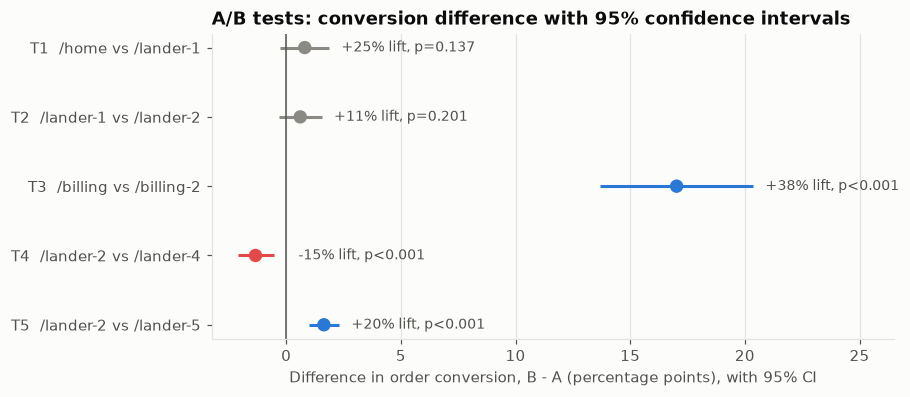

In [35]:
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(summary))[::-1]
diff_pp = summary["conv_diff"] * 100
colors = [HIGHLIGHT if d == "A wins" else VARIANT_COLORS["B"] if d == "B wins" else VARIANT_COLORS["A"]
          for d in summary["decision"]]
ax.errorbar(diff_pp, y,
            xerr=[diff_pp - summary["conv_diff_ci_low"] * 100, summary["conv_diff_ci_high"] * 100 - diff_pp],
            fmt="none", ecolor=colors, elinewidth=2, capsize=0)
ax.scatter(diff_pp, y, color=colors, s=60, zorder=3)
ax.axvline(0, color=TEXT_MUTED, linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels([f"{r.test}  {r.name}" for r in summary.itertuples()])
for yi, r in zip(y, summary.itertuples()):
    p_text = "p<0.001" if r.conv_p_value < 0.001 else f"p={r.conv_p_value:.3f}"
    ax.annotate(f"{r.conv_rel_lift:+.0%} lift, {p_text}", (max(r.conv_diff_ci_high * 100, 0), yi),
                xytext=(8, 0), textcoords="offset points", va="center", fontsize=9, color=TEXT_MUTED)
ax.set_xlabel("Difference in order conversion, B - A (percentage points), with 95% CI")
ax.set_title("A/B tests: conversion difference with 95% confidence intervals")
ax.grid(axis="y", visible=False)
ax.set_xlim(right=ax.get_xlim()[1] + 5)
fig.savefig(IMAGES / "ab_test_results.png")
plt.show()

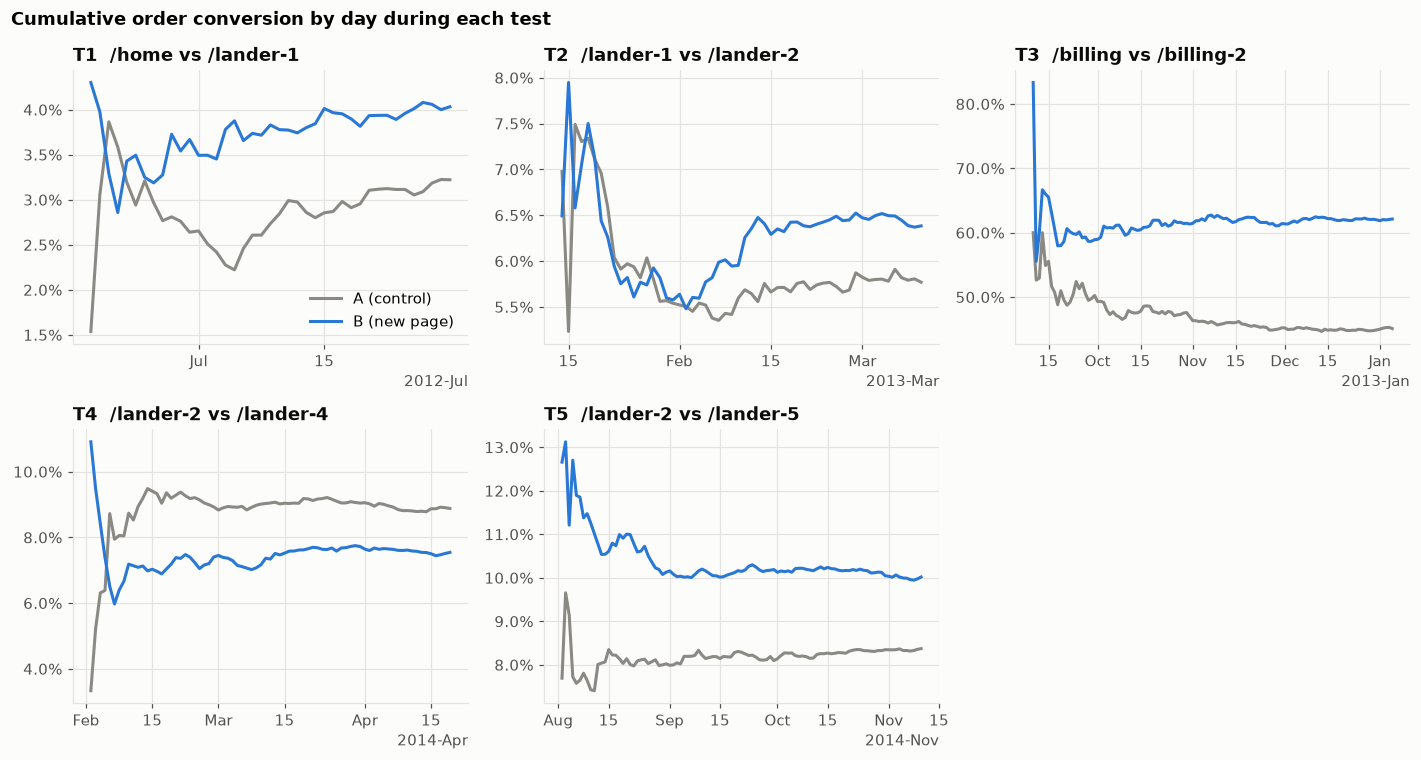

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (key, t) in zip(axes.flat, {"T1": t1, "T2": t2, "T3": t3, "T4": t4, "T5": t5}.items()):
    plot_cumulative(ax, t, f"{key}  {TEST[key]['name']}")
axes.flat[0].legend(loc="lower right")
axes.flat[-1].axis("off")
fig.suptitle("Cumulative order conversion by day during each test", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(IMAGES / "ab_cumulative_conversion.png")
plt.show()

## Not a test: the mobile switch to /lander-3

On 2013-07-09 paid nonbrand **mobile** traffic moved from /lander-2 to /lander-3 with no overlap. Without a
concurrent control, the only option is a before/after comparison, which cannot separate the page effect from
anything else that changed in those weeks (bids, season, other site changes). The numbers below are descriptive only.

In [37]:
mobile_nb = sessions.query("channel_group == 'paid_nonbrand' and device_type == 'mobile'")
cutover = pd.Timestamp("2013-07-09")
pre = mobile_nb[(mobile_nb["created_at"] >= cutover - pd.Timedelta(weeks=4)) & (mobile_nb["created_at"] < cutover)]
post = mobile_nb[(mobile_nb["created_at"] >= cutover) & (mobile_nb["created_at"] < cutover + pd.Timedelta(weeks=4))]
prepost = pd.DataFrame({
    "landing pages": [pre["landing_page"].unique(), post["landing_page"].unique()],
    "sessions": [len(pre), len(post)],
    "bounce_rate": [pre["is_bounce"].mean(), post["is_bounce"].mean()],
    "conv_rate": [pre["has_order"].mean(), post["has_order"].mean()],
}, index=["4 weeks before", "4 weeks after"])
display(prepost)
compare_rates(pre["has_order"].sum(), len(pre), post["has_order"].sum(), len(post))

,landing pages,sessions,bounce_rate,conv_rate
4 weeks before,[/lander-2],1385,0.5870,0.0245
4 weeks after,[/lander-3],1241,0.4746,0.0379


{'rate_a': np.float64(0.02454873646209386),
 'rate_b': np.float64(0.0378726833199033),
 'diff': np.float64(0.013323946857809441),
 'ci_low': np.float64(-6.300625005332093e-05),
 'ci_high': np.float64(0.026710899965672205),
 'rel_lift': np.float64(0.5427548940607669),
 'z': np.float64(1.9715356175697665),
 'p_value_z': np.float64(0.04866264315575975),
 'chi2': np.float64(3.8869526913461985),
 'p_value_chi2': np.float64(0.048662643155759876)}

## Pitfalls to keep in mind

- **Peeking and stopping early.** Checking the p-value every day and stopping the first time it dips below 0.05 raises
  the false-positive rate well above 5%, because random swings cross the line at some point. The cumulative charts
  above show how much the rates move in the first days. Fix the sample size (from a power calculation) before the
  test starts, or use a sequential method designed for repeated looks.
- **Multiple testing.** Many tests, or many metrics and segments in one test, mean some "wins" are luck.
  Pick one primary metric in advance and correct across tests (Holm above).
- **Novelty effects.** Returning visitors may react to a new page just because it is new, and the effect fades.
  Here the risk is small: paid nonbrand sessions in this data are all first-time visitors. The first-half vs
  second-half lift and the post-rollout rates are the checks for it.
- **Statistical vs practical significance.** A tiny lift can be significant with enough traffic, and a large lift can
  be non-significant in a small test. Always report the CI and the impact in orders and revenue, not just the p-value.
- **SRM and segment definition.** Check the split first, and analyse the population the test actually ran on.

**Interpretation (lander-3)**
- Paid nonbrand mobile, 4 weeks before vs after: bounce 58.7% to 47.5%, conversion 2.45% to 3.79% (p = 0.049).
- The direction is encouraging, but with no control group this cannot be credited to the page. It should have been
  run as a 50/50 test.

## Overall conclusions

- Two clear wins: /billing-2 (+37.7% billing-to-order conversion) and /lander-5 (+19.7% order conversion).
  Together they are worth about $15,500 a month at test-period traffic.
- One clear loss, correctly not rolled out: /lander-4 (-15.1%).
- Two landers (/lander-1, /lander-2) cut bounce significantly, but their conversion gains (+25% and +11%) were within
  noise because the tests were too small for effects of that size.
- After the Holm correction, T3, T4 and T5 stay significant (adjusted p <= 0.003); T1 and T2 do not (adjusted p = 0.27).
- No SRM problems and no Simpson's paradox in any test: the device and source mix was balanced in every one.
- Process lesson: size tests before launch. T1 needed about 3.6 times its traffic and T2 about 4.8 times to detect
  the lift they showed.